In [1]:
# Cell 1
%pip install langgraph langchain-groq python-dotenv matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


In [2]:
# Cell 2
import json
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile")

def generate_content(prompt: str) -> str:
    """Helper function to generate content using Groq"""
    response = model.invoke(prompt)
    return response.content.strip()

test_response = generate_content("Say hello in one sentence.")
print(f"Groq API working: {test_response}")

Groq API working: Hello, it's nice to meet you and I'm looking forward to our conversation.


In [3]:
# Cell 3 - State Schema
class AgentState(TypedDict, total=False):
    claim: str
    original_claim: str
    # Phase 1 outputs
    neutral_response: str
    verdict: str
    evidence: str
    influencer_content: str
    amplification_score: int
    moderation_decision: str
    # Phase 2 outputs (cross-agent refined)
    neutral_response_p2: str
    verdict_p2: str
    evidence_p2: str
    influencer_content_p2: str
    amplification_score_p2: int
    moderation_decision_p2: str

In [4]:
# Cell 4 - Misinformation Agent
def misinformation_agent(state: AgentState) -> AgentState:
    """Generates a realistic, plausible news-style claim using LLM."""
    prompt = """
    Generate a short, realistic news-style claim that sounds plausible.
    It may be real or fake. Topics: current events, technology, health, or politics.
    Under 2 sentences. No disclaimers.
    """
    claim = generate_content(prompt)
    print(f"🟥 MISINFORMATION AGENT")
    print(f"Generated Claim: {claim}\n")
    return {"claim": claim, "original_claim": claim}

In [5]:
# Cell 5 - Phase 1 Agents (run in parallel, independent)

def neutral_agent_p1(state: AgentState) -> AgentState:
    """Simulates a typical user sharing the claim without verification."""
    claim = state["claim"]
    response = f"[Shared without verification]: {claim}"
    print(f"🟦 NEUTRAL AGENT (Phase 1)")
    print(f"Sharing claim as-is: {claim}\n")
    return {"neutral_response": response}


def fact_checker_agent_p1(state: AgentState) -> AgentState:
    """Verifies the claim using LLM analysis."""
    claim = state["claim"]
    prompt = f"""
    You are a professional fact-checking AI.
    Analyze the following claim:
    "{claim}"
    Respond STRICTLY in this format (no extra text):
    VERDICT: Real | Fake | Unverified
    EVIDENCE: <short explanation in 2-3 sentences>
    """
    text = generate_content(prompt)

    verdict = "Unverified"
    evidence = "Could not parse response."

    if "VERDICT:" in text:
        verdict_line = text.split("VERDICT:")[1].split("\n")[0].strip()
        if "Fake" in verdict_line:
            verdict = "Fake"
        elif "Real" in verdict_line:
            verdict = "Real"
    if "EVIDENCE:" in text:
        evidence = text.split("EVIDENCE:")[1].strip()

    print(f"🟩 FACT-CHECKER AGENT (Phase 1)")
    print(f"Claim: {claim}")
    print(f"Verdict: {verdict}")
    print(f"Evidence: {evidence}\n")
    return {"verdict": verdict, "evidence": evidence}


def influencer_agent_p1(state: AgentState) -> AgentState:
    """Rewrites the claim for social media virality."""
    claim = state["claim"]
    prompt = f"Rewrite this claim to maximize virality on social media. Keep it engaging.\nClaim: {claim}"
    influenced = generate_content(prompt)
    print(f"🟨 INFLUENCER AGENT (Phase 1)")
    print(f"Influenced Content: {influenced}")
    print(f"Amplification Score: 7/10\n")
    return {"influencer_content": influenced, "amplification_score": 7}


def moderator_agent_p1(state: AgentState) -> AgentState:
    """Makes initial content moderation decision."""
    claim = state["claim"]
    prompt = f"""
    You are a content moderator AI. Analyze this claim:
    "{claim}"
    Should this be: Allowed | Flagged | Blocked?
    Respond in one word.
    """
    decision_text = generate_content(prompt)
    if "Block" in decision_text:
        decision = "Flag & Stop"
    elif "Flag" in decision_text:
        decision = "Mark for Review"
    else:
        decision = "Allow"
    print(f"🟪 MODERATOR AGENT (Phase 1)")
    print(f"Claim: {claim}")
    print(f"Decision: {decision}\n")
    return {"moderation_decision": decision}


# ===== Phase 2 Agents (fully cross-connected, each reads ALL Phase 1 outputs) =====

def neutral_agent_p2(state: AgentState) -> AgentState:
    """Re-evaluates sharing decision using fact-check, influencer, and moderator outputs."""
    claim = state["claim"]
    verdict = state.get("verdict", "Unknown")
    evidence = state.get("evidence", "N/A")
    influencer_content = state.get("influencer_content", "N/A")
    moderation_decision = state.get("moderation_decision", "N/A")

    prompt = f"""You are a neutral social media user. You initially shared a claim without checking.
Now you have access to:
- Fact-check verdict: {verdict} | Evidence: {evidence}
- Influencer version: {influencer_content}
- Moderator decision: {moderation_decision}

Original claim: "{claim}"

Based on ALL the above, write a short updated response (2-3 sentences) on how you would now share or retract this claim."""
    response = generate_content(prompt)
    print(f"🟦 NEUTRAL AGENT (Phase 2 - Cross-Connected)")
    print(f"Updated Response: {response}\n")
    return {"neutral_response_p2": response}


def fact_checker_agent_p2(state: AgentState) -> AgentState:
    """Refines verdict using influencer amplification, neutral sharing, and moderator input."""
    claim = state["claim"]
    neutral_response = state.get("neutral_response", "N/A")
    influencer_content = state.get("influencer_content", "N/A")
    amplification_score = state.get("amplification_score", 0)
    moderation_decision = state.get("moderation_decision", "N/A")

    prompt = f"""You are a fact-checking AI doing a second-pass review.
You now have context from other agents:
- Neutral user response: {neutral_response}
- Influencer rewrite: {influencer_content} (amplification: {amplification_score}/10)
- Moderator decision: {moderation_decision}

Original claim: "{claim}"

Provide a refined analysis. Respond STRICTLY:
VERDICT: Real | Fake | Unverified
EVIDENCE: <2-3 sentences incorporating cross-agent insights>"""
    text = generate_content(prompt)

    verdict = "Unverified"
    evidence = "Could not parse response."
    if "VERDICT:" in text:
        verdict_line = text.split("VERDICT:")[1].split("\n")[0].strip()
        if "Fake" in verdict_line:
            verdict = "Fake"
        elif "Real" in verdict_line:
            verdict = "Real"
    if "EVIDENCE:" in text:
        evidence = text.split("EVIDENCE:")[1].strip()

    print(f"🟩 FACT-CHECKER AGENT (Phase 2 - Cross-Connected)")
    print(f"Refined Verdict: {verdict}")
    print(f"Refined Evidence: {evidence}\n")
    return {"verdict_p2": verdict, "evidence_p2": evidence}


def influencer_agent_p2(state: AgentState) -> AgentState:
    """Adjusts viral content based on fact-check, neutral, and moderator feedback."""
    claim = state["claim"]
    verdict = state.get("verdict", "Unknown")
    evidence = state.get("evidence", "N/A")
    neutral_response = state.get("neutral_response", "N/A")
    moderation_decision = state.get("moderation_decision", "N/A")

    prompt = f"""You are a social media influencer AI. You previously amplified a claim.
Now you have feedback from other agents:
- Fact-check: {verdict} | Evidence: {evidence}
- Neutral user: {neutral_response}
- Moderator: {moderation_decision}

Original claim: "{claim}"

Write an updated social media post (2-3 sentences) that accounts for this feedback.
Also rate your new amplification confidence 1-10."""
    text = generate_content(prompt)

    score = 5
    for i in range(10, 0, -1):
        if str(i) in text:
            score = i
            break

    print(f"🟨 INFLUENCER AGENT (Phase 2 - Cross-Connected)")
    print(f"Updated Content: {text}")
    print(f"New Amplification Score: {score}/10\n")
    return {"influencer_content_p2": text, "amplification_score_p2": score}


def moderator_agent_p2(state: AgentState) -> AgentState:
    """Makes final moderation decision using all agent outputs."""
    claim = state["claim"]
    verdict = state.get("verdict", "Unknown")
    evidence = state.get("evidence", "N/A")
    neutral_response = state.get("neutral_response", "N/A")
    influencer_content = state.get("influencer_content", "N/A")
    amplification_score = state.get("amplification_score", 0)

    prompt = f"""You are a content moderator AI making a FINAL decision.
You have all agent outputs:
- Fact-check: {verdict} | Evidence: {evidence}
- Neutral user: {neutral_response}
- Influencer: {influencer_content} (amplification: {amplification_score}/10)

Original claim: "{claim}"

Make your final moderation decision: Allow | Flag | Block
Explain in 1-2 sentences."""
    text = generate_content(prompt)

    if "Block" in text:
        decision = "BLOCKED"
    elif "Flag" in text:
        decision = "FLAGGED"
    else:
        decision = "ALLOWED"

    print(f"🟪 MODERATOR AGENT (Phase 2 - Cross-Connected)")
    print(f"Final Decision: {decision}")
    print(f"Reasoning: {text}\n")
    return {"moderation_decision_p2": decision}

In [6]:
# Cell 6 - Build the Fully Cross-Connected Graph

builder = StateGraph(AgentState)

# Phase 1 nodes
builder.add_node("misinformation", misinformation_agent)
builder.add_node("neutral_p1", neutral_agent_p1)
builder.add_node("fact_checker_p1", fact_checker_agent_p1)
builder.add_node("influencer_p1", influencer_agent_p1)
builder.add_node("moderator_p1", moderator_agent_p1)

# Phase 2 nodes (cross-connected)
builder.add_node("neutral_p2", neutral_agent_p2)
builder.add_node("fact_checker_p2", fact_checker_agent_p2)
builder.add_node("influencer_p2", influencer_agent_p2)
builder.add_node("moderator_p2", moderator_agent_p2)

# START -> misinformation
builder.add_edge(START, "misinformation")

# misinformation fans out to all Phase 1 agents
builder.add_edge("misinformation", "neutral_p1")
builder.add_edge("misinformation", "fact_checker_p1")
builder.add_edge("misinformation", "influencer_p1")
builder.add_edge("misinformation", "moderator_p1")

# FULL CROSS-CONNECTIVITY:
# Each Phase 1 agent connects to EVERY Phase 2 agent
# This means each P2 agent receives outputs from ALL P1 agents

p1_nodes = ["neutral_p1", "fact_checker_p1", "influencer_p1", "moderator_p1"]
p2_nodes = ["neutral_p2", "fact_checker_p2", "influencer_p2", "moderator_p2"]

for p1 in p1_nodes:
    for p2 in p2_nodes:
        builder.add_edge(p1, p2)

# All Phase 2 agents converge to END
for p2 in p2_nodes:
    builder.add_edge(p2, END)

graph = builder.compile()
print("✅ Fully cross-connected pipeline compiled successfully!")

✅ Fully cross-connected pipeline compiled successfully!


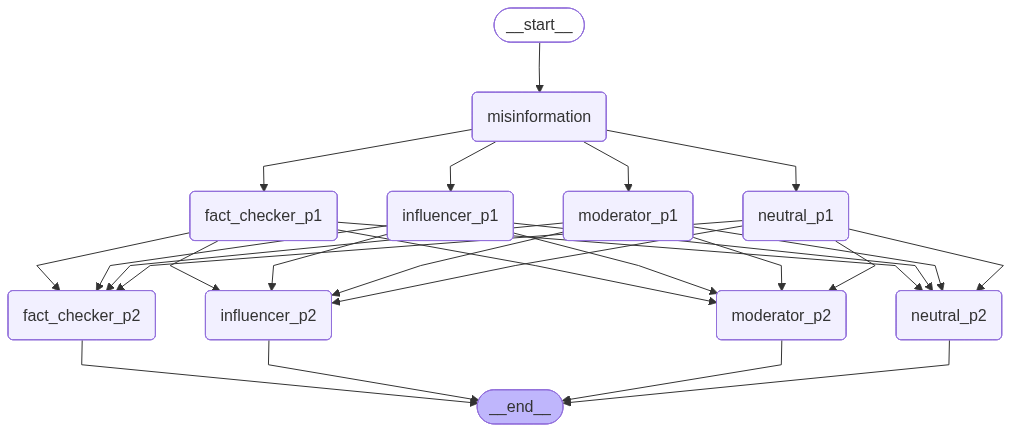

In [7]:
# Cell 7 - Visualize the Graph
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [8]:
# Cell 8 - Run the Pipeline
result = graph.invoke({})

print("=" * 60)
print("📊 FINAL MULTI-AGENT REPORT (FULLY CROSS-CONNECTED)")
print("=" * 60)

print(f"\n📰 Original Claim:\n   {result.get('original_claim', 'N/A')}")

print(f"\n{'─' * 60}")
print("⚡ PHASE 1 — Independent Analysis")
print(f"{'─' * 60}")
print(f"\n🟦 Neutral Response:\n   {result.get('neutral_response', 'N/A')}")
print(f"\n🟩 Fact-Check Verdict: {result.get('verdict', 'N/A')}")
print(f"   Evidence: {result.get('evidence', 'N/A')}")
print(f"\n🟨 Influencer Content:\n   {result.get('influencer_content', 'N/A')}")
print(f"   Amplification Score: {result.get('amplification_score', 0)}/10")
print(f"\n🟪 Moderation Decision: {result.get('moderation_decision', 'N/A')}")

print(f"\n{'─' * 60}")
print("🔗 PHASE 2 — Cross-Connected Refined Analysis")
print(f"{'─' * 60}")
print(f"\n🟦 Neutral (Refined):\n   {result.get('neutral_response_p2', 'N/A')}")
print(f"\n🟩 Fact-Check (Refined): {result.get('verdict_p2', 'N/A')}")
print(f"   Evidence: {result.get('evidence_p2', 'N/A')}")
print(f"\n🟨 Influencer (Refined):\n   {result.get('influencer_content_p2', 'N/A')}")
print(f"   Amplification Score: {result.get('amplification_score_p2', 0)}/10")
print(f"\n🟪 Moderation (Final): {result.get('moderation_decision_p2', 'N/A')}")

print(f"\n{'=' * 60}")
print("\n📋 Raw JSON:")
print(json.dumps(result, indent=2))

🟥 MISINFORMATION AGENT
Generated Claim: A recent study published in a prominent medical journal has found that a new gene-editing technique may be able to reverse the effects of certain neurodegenerative diseases, offering new hope to patients and families affected by these conditions. Researchers are now working to bring this treatment to clinical trials.

🟦 NEUTRAL AGENT (Phase 1)
Sharing claim as-is: A recent study published in a prominent medical journal has found that a new gene-editing technique may be able to reverse the effects of certain neurodegenerative diseases, offering new hope to patients and families affected by these conditions. Researchers are now working to bring this treatment to clinical trials.

🟪 MODERATOR AGENT (Phase 1)
Claim: A recent study published in a prominent medical journal has found that a new gene-editing technique may be able to reverse the effects of certain neurodegenerative diseases, offering new hope to patients and families affected by these con